# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Student Performance**. Dataset ini berisi informasi kebiasaan belajar dan performa siswa, seperti `Hours Studied`, `Previous Scores`, `Extracurricular Activities`, `Sleep Hours`, `Sample Question Papers Practiced`, dan target `Performance Index`.

Tujuan eksperimen ini adalah menyiapkan dataset mentah menjadi dataset yang siap digunakan untuk pelatihan model machine learning. Proses yang dilakukan meliputi data loading, exploratory data analysis, encoding fitur kategorikal, pembersihan data, feature engineering, scaling, dan pembagian data train-test.

# **2. Import Library**

Pada tahap ini, library yang dibutuhkan untuk data loading, EDA, preprocessing, dan pembagian dataset diimpor terlebih dahulu.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, dataset mentah dimuat menggunakan pandas. Setelah dataset dimuat, beberapa baris awal dan informasi umum dataset ditampilkan untuk memastikan struktur data sudah terbaca dengan benar.

In [2]:
file_path = "Student_Performance_raw/Student_Performance.csv"
df = pd.read_csv(file_path)
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


# **4. Exploratory Data Analysis (EDA)**

EDA dilakukan untuk melihat karakteristik awal dataset, jumlah nilai kosong, duplikasi data, distribusi fitur, serta hubungan antar fitur numerik.

In [4]:
print("Jumlah baris dan kolom:", df.shape)
print("\nMissing value per kolom:")
print(df.isnull().sum())
print("\nJumlah duplikasi:", df.duplicated().sum())

Jumlah baris dan kolom: (10000, 6)

Missing value per kolom:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Jumlah duplikasi: 127


In [5]:
print(df["Extracurricular Activities"].value_counts())

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64


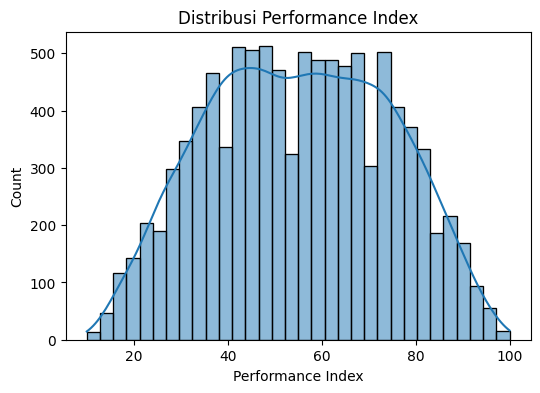

In [6]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Performance Index"], kde=True)
plt.title("Distribusi Performance Index")
plt.show()

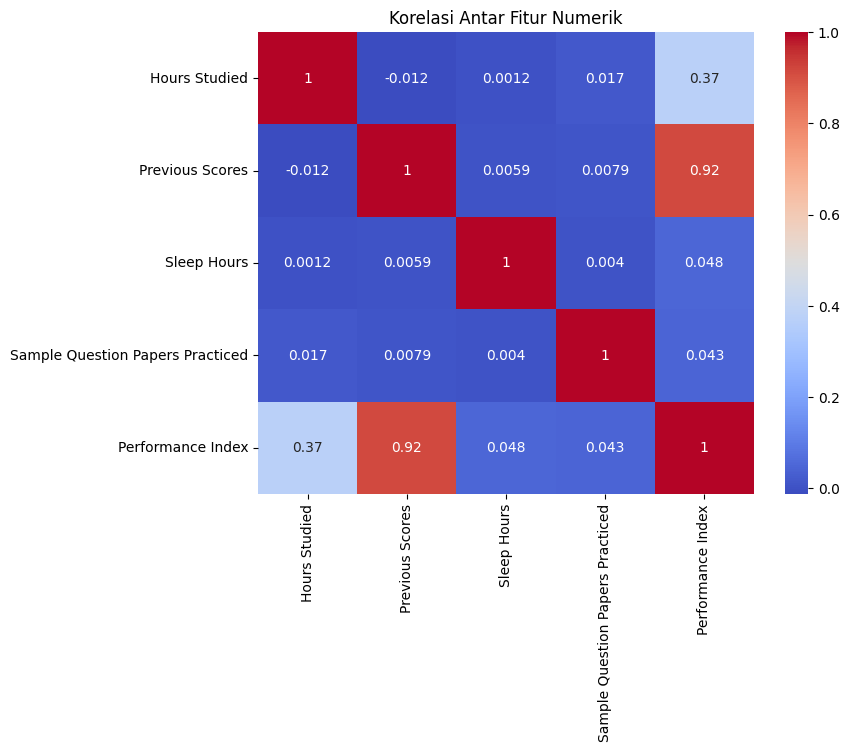

In [7]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

# **5. Data Preprocessing**

Tahap preprocessing dilakukan dengan membersihkan nama kolom, melakukan encoding pada fitur kategorikal, membuat fitur baru `study_efficiency`, menghapus missing value dan duplikasi, membagi data menjadi train-test, melakukan scaling pada fitur numerik, lalu menyimpan hasil preprocessing agar siap digunakan untuk pelatihan model.

In [8]:
# 1. Membersihkan nama kolom
df.columns = df.columns.str.strip()

# 2. Encoding fitur kategorikal
df["Extracurricular Activities"] = (
    df["Extracurricular Activities"].astype(str).str.strip().str.title().map({"Yes": 1, "No": 0})
)

# 3. Feature engineering
df["study_efficiency"] = df["Hours Studied"] / df["Sleep Hours"]

# 4. Membersihkan missing value dan duplikasi
df = df.dropna().drop_duplicates()

# 5. Memisahkan fitur dan target
target_col = "Performance Index"
X = df.drop(columns=[target_col])
y = df[target_col]

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Scaling fitur numerik
num_cols = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced",
    "study_efficiency",
]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 8. Menyimpan dataset hasil preprocessing
output_dir = "preprocessing/Student_Performance_preprocessing"
os.makedirs(output_dir, exist_ok=True)
X_train.to_csv(f"{output_dir}/X_train.csv", index=False)
X_test.to_csv(f"{output_dir}/X_test.csv", index=False)
y_train.to_csv(f"{output_dir}/y_train.csv", index=False)
y_test.to_csv(f"{output_dir}/y_test.csv", index=False)

print("Preprocessing selesai")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Preprocessing selesai
X_train: (7898, 6)
X_test: (1975, 6)
y_train: (7898,)
y_test: (1975,)
